In [ ]:
import os
import io
import time
import base64
from pathlib import Path
from getpass import getpass
import fitz
import pandas as pd
from PIL import Image
from IPython.display import display
from groq import Groq
from pinecone import Pinecone,ServerlessSpec
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_pinecone import PineconeVectorStore
 

c:\Users\Lenovo\Desktop\Multimodel Rag\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PDF and Model Configuration

In [14]:

PDF_PATH = Path(r"C:\Users\Lenovo\Desktop\Multimodel Rag\documents\NovaCore_Multimodal_Company_Report_2026.pdf")

if PDF_PATH.exists():
    print("Exist")
else:
    print("Not Exist")

Exist


In [15]:
TEXT_MODEL = "openai/gpt-oss-20b"
VISION_MODEL = "qwen/qwen3.8-27b"
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

PINECONE_INDEX_NAME = "novacore-multimodal-rag"
PINECONE_NAMESPACE = "fy2026-demo"

IMAGE_DIR = Path("novacore_extracted_images")
IMAGE_DIR.mkdir(exist_ok=True)

print("PDF:", PDF_PATH)
print("Pinecone index:", PINECONE_INDEX_NAME)
print("Pinecone namespace:", PINECONE_NAMESPACE)

PDF: C:\Users\Lenovo\Desktop\Multimodel Rag\documents\NovaCore_Multimodal_Company_Report_2026.pdf
Pinecone index: novacore-multimodal-rag
Pinecone namespace: fy2026-demo


In [16]:
import os
from dotenv import load_dotenv
from groq import Groq
from langchain_groq import ChatGroq

load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found in .env")

if not PINECONE_API_KEY:
    raise ValueError("PINECONE_API_KEY not found in .env")

groq_client = Groq(api_key=GROQ_API_KEY)

text_llm = ChatGroq(
    model=TEXT_MODEL,
    temperature=0,
)

print("API clients are ready.")

API clients are ready.


Image Convert to Base64

In [17]:
def image_to_data_uri(image_path):
    image_path = Path(image_path)

    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img.thumbnail((1600, 1600))

        buffer = io.BytesIO()
        img.save(buffer, format="JPEG", quality=85)

    encoded = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return f"data:image/jpeg;base64,{encoded}"
     

summarize images, charts, and diagrams


In [18]:
def summarize_visual(image_path, page_number):
    image_data = image_to_data_uri(image_path)

    prompt = f"""
This visual was extracted from page {page_number} of the NovaCore FY2026 company report.

Describe the useful business information visible in the visual.

If it is a chart or graph:
- mention important values
- mention highest/lowest values
- mention the main trend

If it is a diagram:
- identify important components
- explain the flow or relationships

If it is a normal business image:
- describe the useful factual information

Keep the description concise and factual.
"""

    response = groq_client.chat.completions.create(
        model=VISION_MODEL,
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {"url": image_data},
                    },
                ],
            }
        ],
        temperature=0,
        max_completion_tokens=500,
    )

    return response.choices[0].message.content.strip()

Extract text, tables, and visuals from the PDF

In [19]:
def extract_multimodal_documents(pdf_path):
    pdf = fitz.open(str(pdf_path))

    documents = []
    extracted_xrefs = set()

    for page_index in range(len(pdf)):
        page = pdf[page_index]
        page_number = page_index + 1

        print(f"Processing page {page_number}...")

        # -------------------------------------------------
        # 1. TEXT
        # -------------------------------------------------
        text = page.get_text("text").strip()

        if text:
            documents.append(
                Document(
                    page_content=text,
                    metadata={
                        "page": page_number,
                        "modality": "text",
                        "source": pdf_path.name,
                    },
                )
            )

        # -------------------------------------------------
        # 2. TABLES
        # -------------------------------------------------
        try:
            tables = page.find_tables().tables

            for table_number, table in enumerate(tables, start=1):
                df = table.to_pandas()

                if not df.empty:
                    table_text = df.to_markdown(index=False)

                    documents.append(
                        Document(
                            page_content=table_text,
                            metadata={
                                "page": page_number,
                                "modality": "table",
                                "table_number": table_number,
                                "source": pdf_path.name,
                            },
                        )
                    )

        except Exception as error:
            print("Table extraction warning:", error)

        # -------------------------------------------------
        # 3. IMAGES / CHARTS / DIAGRAMS
        # -------------------------------------------------
        for image_number, image_info in enumerate(
            page.get_images(full=True),
            start=1,
        ):
            xref = image_info[0]

            # Do not process an identical embedded image twice.
            if xref in extracted_xrefs:
                continue

            extracted_xrefs.add(xref)

            image_data = pdf.extract_image(xref)
            image_bytes = image_data["image"]
            image_extension = image_data["ext"]

            image_path = (
                IMAGE_DIR
                / f"page_{page_number}_image_{image_number}.{image_extension}"
            )

            image_path.write_bytes(image_bytes)

            try:
                summary = summarize_visual(
                    image_path=image_path,
                    page_number=page_number,
                )

                documents.append(
                    Document(
                        page_content=summary,
                        metadata={
                            "page": page_number,
                            "modality": "visual",
                            "image_path": str(image_path),
                            "source": pdf_path.name,
                        },
                    )
                )

            except Exception as error:
                print(
                    f"Vision warning on page {page_number}:",
                    error,
                )

    pdf.close()
    return documents


documents = extract_multimodal_documents(PDF_PATH)

print()
print("Total LangChain documents:", len(documents))

Processing page 1...
Consider using the pymupdf_layout package for a greatly improved page layout analysis.
Processing page 2...
Processing page 3...
Processing page 4...
Processing page 5...
Processing page 6...
Processing page 7...
Processing page 8...
Processing page 9...

Total LangChain documents: 24


In [20]:
documents

[Document(metadata={'page': 1, 'modality': 'text', 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='NovaCore Systems Ltd. - Fictional company report created for a multimodal RAG demonstration\nPage 1\nNOVACORE SYSTEMS LTD.\nFY2026 BUSINESS PERFORMANCE &\nOPERATIONS REPORT\nA realistic fictional company document designed for multimodal RAG testing\nHeadquarters\nSingapore\nEmployees\n1,480\n2026 Revenue\n$132.0M\nOperating Margin\n18.4%\nPrimary Sector\nIndustrial AI & IoT\nMarkets Served\n42 countries\nDemo note: All company names, metrics, people, and events in this report are fictional. The document intentionally mixes text, tables,\ncharts, and embedded images so it can be used to demonstrate multimodal retrieval and question answering.'),
 Document(metadata={'page': 1, 'modality': 'table', 'table_number': 1, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='| Headquarters   | Singapore           | Employees        | 1,480        |\n|:---

 Inspect extracted content

In [22]:
rows = []

for doc in documents:
    rows.append(
        {
            "page": doc.metadata["page"],
            "modality": doc.metadata["modality"],
            "preview": doc.page_content[:140].replace("\n", " "),
        }
    )

summary_df = pd.DataFrame(rows)

display(summary_df)

print("Documents by modality:")
display(summary_df["modality"].value_counts())

,page,modality,preview
0,1,text,NovaCore Systems Ltd. - Fictional company repo...
1,1,table,| Headquarters | Singapore | Emplo...
2,1,visual,Based on the visual from the NovaCore FY2026 c...
3,2,text,NovaCore Systems Ltd. - Fictional company repo...
4,2,table,| Priority | 2026 target ...
5,3,text,NovaCore Systems Ltd. - Fictional company repo...
6,3,table,| Metric | FY2025 | FY2026 | Cha...
7,3,visual,"Based on the visual provided, here is the desc..."
8,4,text,NovaCore Systems Ltd. - Fictional company repo...
9,4,table,| Region | 2026 revenue | YoY growth ...


Documents by modality:


modality
text      9
table     8
visual    7
Name: count, dtype: int64

 Create embeddings

In [23]:
embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    encode_kwargs={"normalize_embeddings": True},
)

# Detect the exact vector dimension automatically.
EMBEDDING_DIMENSION = len(
    embeddings.embed_query("dimension check")
)

print("Embedding model:", EMBEDDING_MODEL)
print("Embedding dimension:", EMBEDDING_DIMENSION)

c:\Users\Lenovo\Desktop\Multimodel Rag\venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\Lenovo\Desktop\Multimodel Rag\venv\Lib\site-packages\huggingface_hub\file_do

Embedding model: sentence-transformers/all-MiniLM-L6-v2
Embedding dimension: 384


Create the Pinecone serverless index

In [24]:
pc = Pinecone(
    api_key=os.environ["PINECONE_API_KEY"]
)

if not pc.has_index(PINECONE_INDEX_NAME):
    print("Creating Pinecone index...")

    pc.create_index(
        name=PINECONE_INDEX_NAME,
        dimension=EMBEDDING_DIMENSION,
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1",
        ),
    )

    # Wait until Pinecone reports that the index is ready.
    while not pc.describe_index(PINECONE_INDEX_NAME).status["ready"]:
        print("Waiting for Pinecone index...")
        time.sleep(2)

    print("Pinecone index created.")
else:
    print("Pinecone index already exists.")

index = pc.Index(PINECONE_INDEX_NAME)

print("Connected to:", PINECONE_INDEX_NAME)

Creating Pinecone index...
Pinecone index created.
Connected to: novacore-multimodal-rag


Clean the demo namespace

In [25]:
try:
    index.delete(
        delete_all=True,
        namespace=PINECONE_NAMESPACE,
    )

    print("Cleared namespace:", PINECONE_NAMESPACE)

except Exception as error:
    print(
        "Namespace was probably empty. Continuing...",
        error,
    )

Namespace was probably empty. Continuing... (404)
Reason: Not Found
HTTP response headers: HTTPHeaderDict({'Date': 'Sat, 26 Sep 2026 05:50:06 GMT', 'Content-Type': 'application/json', 'Content-Length': '55', 'Connection': 'keep-alive', 'x-pinecone-request-latency-ms': '31', 'x-envoy-upstream-service-time': '32', 'x-pinecone-response-duration-ms': '33', 'server': 'envoy'})
HTTP response body: {"code":5,"message":"Namespace not found","details":[]}



Store LangChain documents in Pinecone

In [26]:
vectorstore = PineconeVectorStore(
    index_name=PINECONE_INDEX_NAME,
    embedding=embeddings,
    namespace=PINECONE_NAMESPACE,
)

vectorstore.add_documents(documents)

print("Documents uploaded to Pinecone.")

Documents uploaded to Pinecone.


Create the Pinecone retriever

In [41]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 5}
)

print("Retriever is ready.")

Retriever is ready.


Test Pinecone retrieval

In [29]:

query = "Which region had the highest revenue growth?"

retrieved_docs = retriever.invoke(query)

for i, doc in enumerate(retrieved_docs, start=1):
    print("=" * 80)
    print(
        f"Result {i} | "
        f"Page {doc.metadata.get('page')} | "
        f"Type: {doc.metadata.get('modality')}"
    )
    print(doc.page_content[:700])
    print()

Result 1 | Page 4.0 | Type: table
| Region        | 2026 revenue   | YoY growth   |   Enterprise customers | CSAT   |
|:--------------|:---------------|:-------------|-----------------------:|:-------|
| Europe        | $41.2M         | 31%          |                    118 | 4.7/5  |
| North America | $38.6M         | 27%          |                    104 | 4.6/5  |
| Asia Pacific  | $34.9M         | 24%          |                     96 | 4.8/5  |
| Middle East   | $17.3M         | 18%          |                     51 | 4.5/5  |

Result 2 | Page 4.0 | Type: visual
Based on the visual provided, here is the description of the business information:

**Chart Type:** Bar Chart
**Title:** 2026 Year-over-Year Revenue Growth by Region

**Key Data Points:**
The chart displays the projected revenue growth percentages for four specific geographic regions for the fiscal year 2026:
*   **Europe:** 31%
*   **North America:** 27%
*   **Asia Pacific:** 24%
*   **Middle East:** 18%

**Analysis:**
* 

Create the LangChain text RAG chain

In [30]:
rag_prompt = ChatPromptTemplate.from_template(
    """
You are a helpful assistant answering questions about the
NovaCore Systems FY2026 company report.

Use ONLY the retrieved context below.

If the answer is not available in the context, say:
"I could not find that information in the report."

Mention page numbers when possible.

CONTEXT:
{context}

QUESTION:
{question}

ANSWER:
"""
)

text_rag_chain = (
    rag_prompt
    | text_llm
    | StrOutputParser()
)

print("Text RAG chain is ready.")

Text RAG chain is ready.


Format retrieved context

In [31]:
def format_context(retrieved_docs):
    parts = []

    for doc in retrieved_docs:
        page = doc.metadata.get("page")
        modality = doc.metadata.get("modality")

        parts.append(
            f"[Page {page} | {modality.upper()}]\n"
            f"{doc.page_content}"
        )

    return "\n\n".join(parts)

Vision answer helper

In [32]:
def answer_with_vision(question, context, image_paths):
    image_paths = image_paths[:3]

    content = [
        {
            "type": "text",
            "text": f"""
You are answering questions about the NovaCore Systems FY2026 report.

Use ONLY the retrieved context and the attached retrieved visuals.

RETRIEVED CONTEXT:
{context}

QUESTION:
{question}

Instructions:
- Answer factually.
- Use the attached visuals when relevant.
- Mention page numbers.
- If the information is missing, say you could not find it.
""",
        }
    ]

    for image_path in image_paths:
        content.append(
            {
                "type": "image_url",
                "image_url": {
                    "url": image_to_data_uri(image_path)
                },
            }
        )

    response = groq_client.chat.completions.create(
        model=VISION_MODEL,
        messages=[
            {
                "role": "user",
                "content": content,
            }
        ],
        temperature=0,
        max_completion_tokens=900,
    )

    return response.choices[0].message.content.strip()

Complete Multimodal RAG function

In [33]:
def ask_rag(question, show_sources=True, show_images=False):

    # 1. Retrieve from Pinecone
    retrieved_docs = retriever.invoke(question)

    # 2. Create context
    context = format_context(retrieved_docs)

    # 3. Check whether Pinecone returned visuals
    image_paths = []

    for doc in retrieved_docs:
        if doc.metadata.get("modality") == "visual":
            image_path = doc.metadata.get("image_path")

            if image_path and Path(image_path).exists():
                image_paths.append(image_path)

    # 4. Generate the answer
    if image_paths:
        answer = answer_with_vision(
            question=question,
            context=context,
            image_paths=image_paths,
        )
    else:
        answer = text_rag_chain.invoke(
            {
                "context": context,
                "question": question,
            }
        )

    print("\nQUESTION:")
    print(question)

    print("\nANSWER:")
    print(answer)

    if show_sources:
        print("\nPINECONE RETRIEVED SOURCES:")

        for i, doc in enumerate(retrieved_docs, start=1):
            print(
                f"{i}. Page {doc.metadata.get('page')} "
                f"| {doc.metadata.get('modality')}"
            )

    if show_images and image_paths:
        print("\nRETRIEVED VISUALS:")

        for image_path in image_paths:
            display(Image.open(image_path))

    return {
        "answer": answer,
        "documents": retrieved_docs,
        "image_paths": image_paths,
    }
     

Demo — Text question

In [34]:

ask_rag(
    "What does NovaCore Systems do and where is the company headquartered?"
)
     


QUESTION:
What does NovaCore Systems do and where is the company headquartered?

ANSWER:
NovaCore Systems Ltd. is an **Industrial AI & IoT** company, and its headquarters are located in **Singapore**【Page 1.0】.

PINECONE RETRIEVED SOURCES:
1. Page 6.0 | text
2. Page 1.0 | text


{'answer': 'NovaCore Systems Ltd. is an **Industrial AI & IoT** company, and its headquarters are located in **Singapore**【Page\u202f1.0】.',
 'documents': [Document(id='4b655a60-0422-4e50-931e-0a984ad9f533', metadata={'modality': 'text', 'page': 6.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='NovaCore Systems Ltd. - Fictional company report created for a multimodal RAG demonstration\nPage 6\n5. Manufacturing & Supply Chain\nInformation-bearing diagram + facility image\nThe supply-chain diagram above contains operational details that are not repeated in full elsewhere. In particular, it\nidentifies the Quality Lab in Singapore as the critical control point before products move to regional distribution\nhubs.\nFigure 3. Penang Smart Assembly Facility. The embedded image carries facility utilization and solar contribution values that can be\nqueried by a multimodal system.'),
  Document(id='c6795689-06ab-4479-9e73-a0e7a14d6318', metadata={'modality': 'text', '

In [35]:
ask_rag(
    "Which region had the highest year-over-year revenue growth?"
)


QUESTION:
Which region had the highest year-over-year revenue growth?

ANSWER:
Based on the bar chart and table on page 4.0, **Europe** had the highest year-over-year revenue growth at **31%**.

PINECONE RETRIEVED SOURCES:
1. Page 4.0 | visual
2. Page 4.0 | table


{'answer': 'Based on the bar chart and table on page 4.0, **Europe** had the highest year-over-year revenue growth at **31%**.',
 'documents': [Document(id='11648dd1-2c00-44c7-841d-e4a308a6daac', metadata={'image_path': 'novacore_extracted_images\\page_4_image_1.png', 'modality': 'visual', 'page': 4.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='Based on the visual provided, here is the description of the business information:\n\n**Chart Type:** Bar Chart\n**Title:** 2026 Year-over-Year Revenue Growth by Region\n\n**Key Data Points:**\nThe chart displays the projected revenue growth percentages for four specific geographic regions for the fiscal year 2026:\n*   **Europe:** 31%\n*   **North America:** 27%\n*   **Asia Pacific:** 24%\n*   **Middle East:** 18%\n\n**Analysis:**\n*   **Highest Value:** Europe is projected to have the highest year-over-year revenue growth at 31%.\n*   **Lowest Value:** The Middle East is projected to have the lowest growth among th


QUESTION:
According to the revenue graph, which quarter had the highest revenue?

ANSWER:
Based on the "Quarterly Revenue Trend" line graph shown on Page 3.0, the quarter with the highest revenue is **Q4 2026**. The graph indicates that revenue reached its peak at approximately 37.5 million USD in this quarter.

PINECONE RETRIEVED SOURCES:
1. Page 3.0 | visual
2. Page 4.0 | visual

RETRIEVED VISUALS:


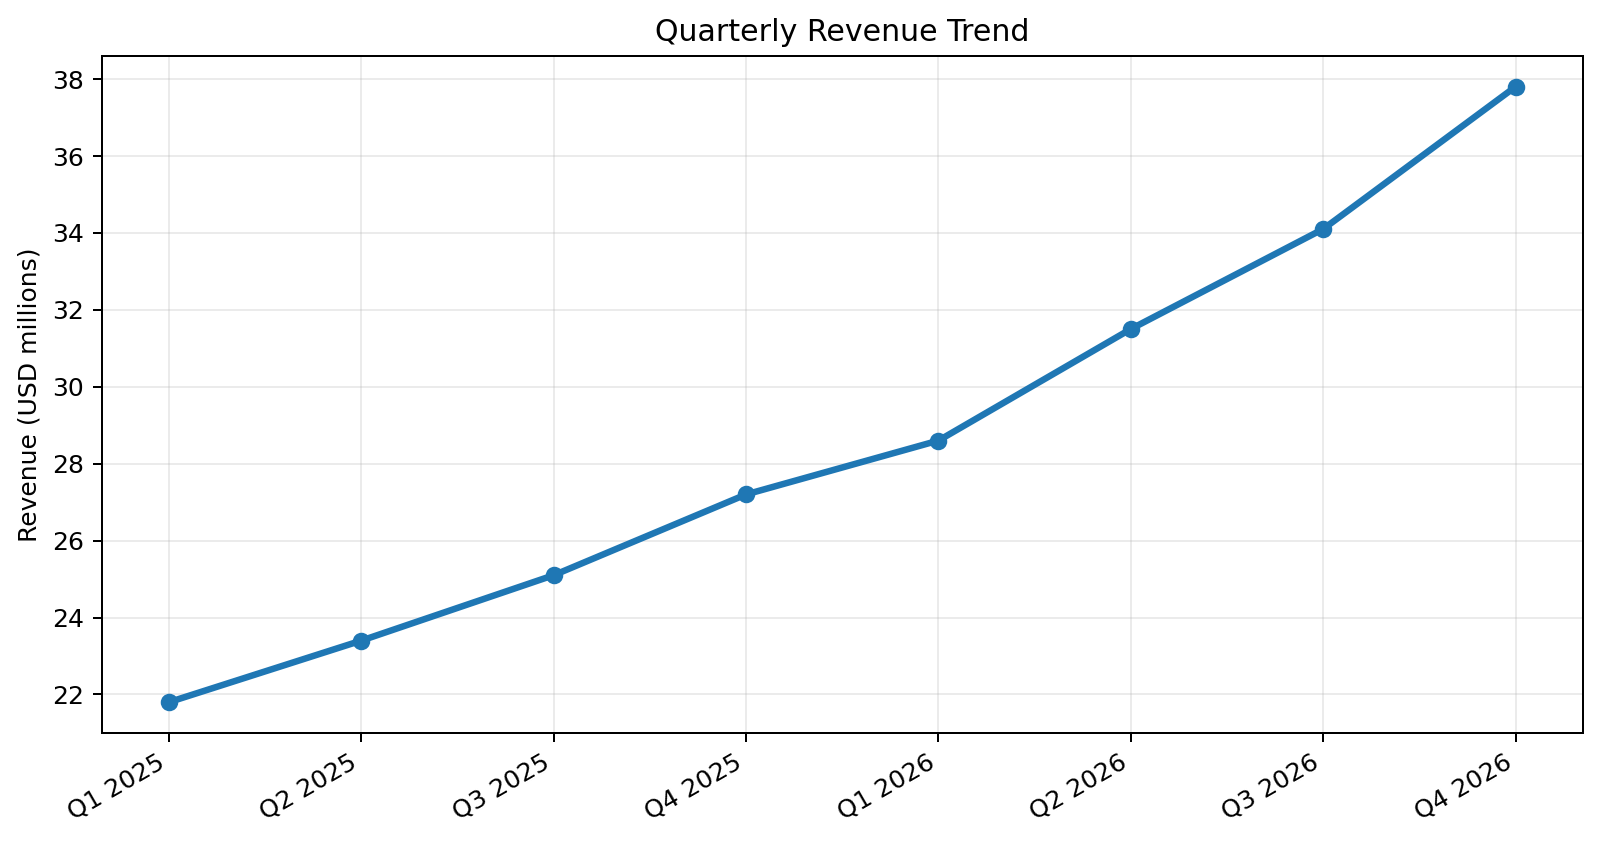

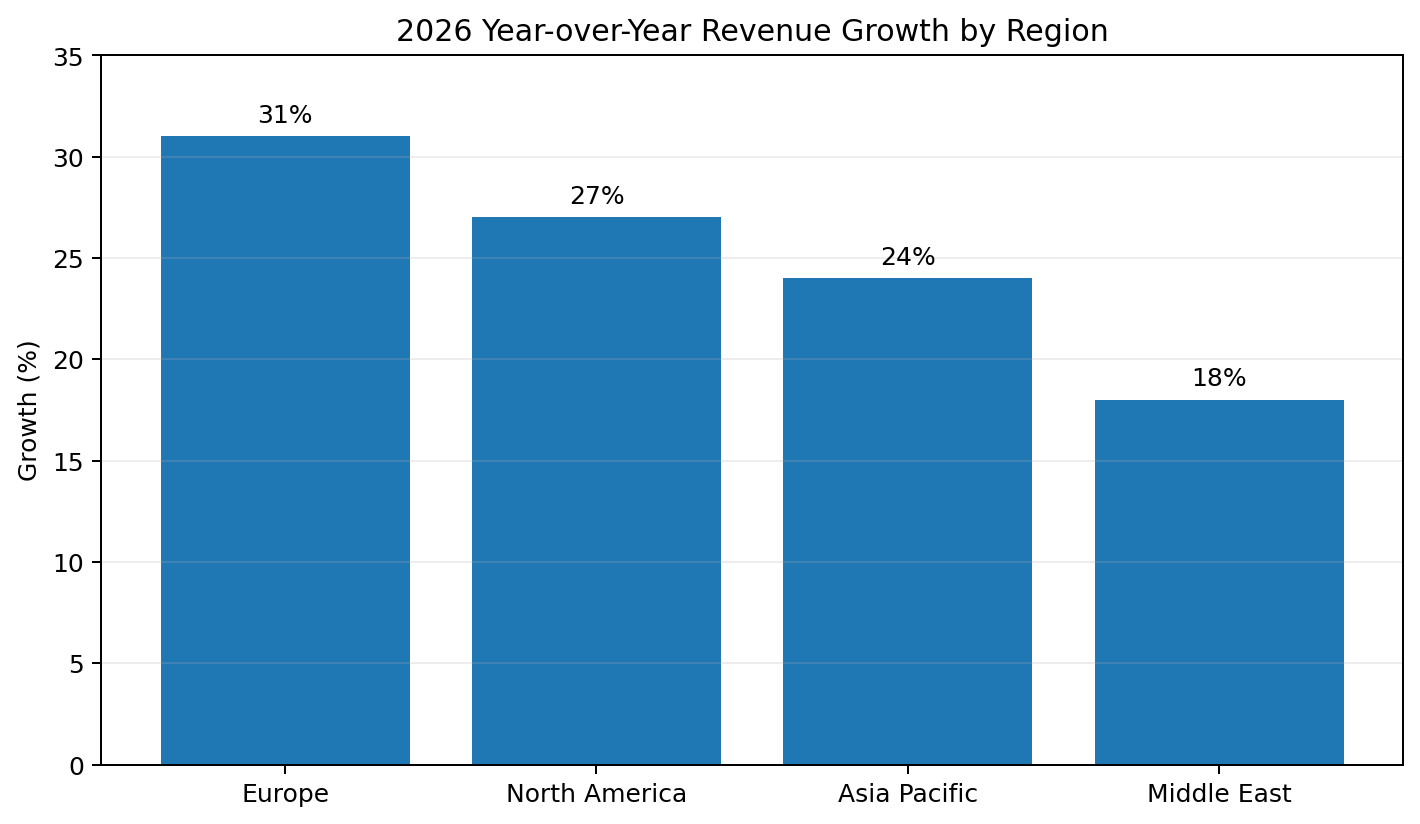

{'answer': 'Based on the "Quarterly Revenue Trend" line graph shown on Page 3.0, the quarter with the highest revenue is **Q4 2026**. The graph indicates that revenue reached its peak at approximately 37.5 million USD in this quarter.',
 'documents': [Document(id='ff1ad4e3-7850-4f71-bbb7-c3dec8f461f3', metadata={'image_path': 'novacore_extracted_images\\page_3_image_1.png', 'modality': 'visual', 'page': 3.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='Based on the visual provided, here is the description of the business information:\n\n**Chart Type:** Line Graph\n**Title:** Quarterly Revenue Trend\n\n**Key Data Points (Revenue in USD millions):**\n*   **Q1 2025:** ~22.0 (Lowest value)\n*   **Q2 2025:** ~23.5\n*   **Q3 2025:** ~25.2\n*   **Q4 2025:** ~27.2\n*   **Q1 2026:** ~28.5\n*   **Q2 2026:** ~31.5\n*   **Q3 2026:** ~34.1\n*   **Q4 2026:** ~37.5 (Highest value)\n\n**Main Trend:**\nThe chart displays a consistent and strong upward trend in revenue over th

In [36]:
ask_rag(
    "According to the revenue graph, which quarter had the highest revenue?",
    show_images=True,
)
     


QUESTION:
According to the supply-chain diagram, what is the critical quality-control point?

ANSWER:
Based on the supply-chain diagram on **Page 6.0**, the critical quality-control point is the **Quality Lab** located in **Singapore**.

The diagram explicitly highlights this stage in a green box labeled "Critical control point: Quality Lab" and notes that "Every production batch must pass thermal, network, and firmware tests before export."

PINECONE RETRIEVED SOURCES:
1. Page 6.0 | visual
2. Page 6.0 | text

RETRIEVED VISUALS:


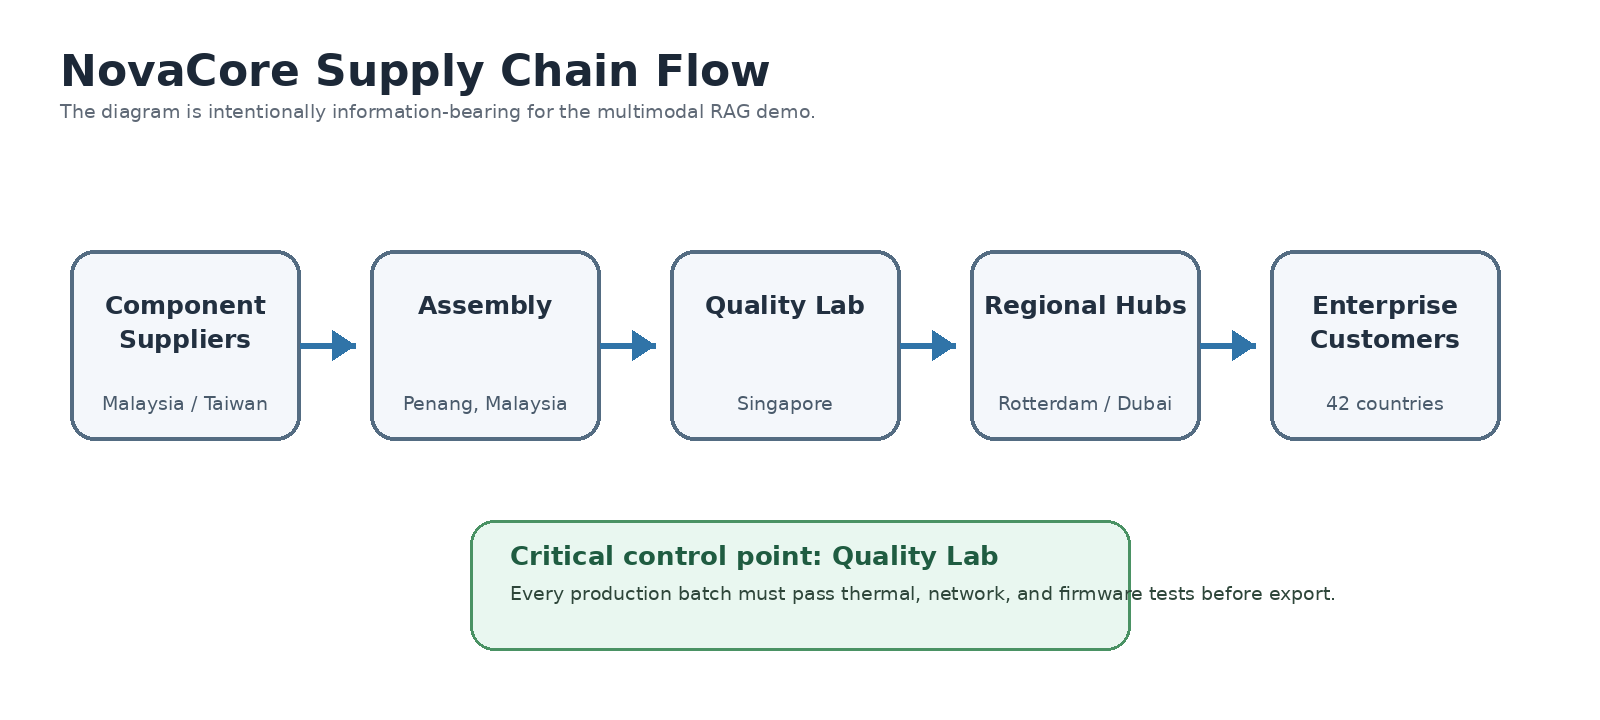

{'answer': 'Based on the supply-chain diagram on **Page 6.0**, the critical quality-control point is the **Quality Lab** located in **Singapore**.\n\nThe diagram explicitly highlights this stage in a green box labeled "Critical control point: Quality Lab" and notes that "Every production batch must pass thermal, network, and firmware tests before export."',
 'documents': [Document(id='10108254-0bca-4de4-a7c5-6473828847bc', metadata={'image_path': 'novacore_extracted_images\\page_6_image_1.png', 'modality': 'visual', 'page': 6.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='Based on the visual provided, here is the description of the business information:\n\n**Diagram Type:** Supply Chain Flow Diagram\n\n**Title:** NovaCore Supply Chain Flow\n\n**Flow and Relationships:**\nThe diagram illustrates a linear, five-stage supply chain process moving from left to right:\n\n1.  **Component Suppliers:** The starting point of the supply chain, located in **Malaysia / T

In [37]:
ask_rag(
    "According to the supply-chain diagram, what is the critical quality-control point?",
    show_images=True,
)
     


QUESTION:
How did average support resolution time change from January to August?

ANSWER:
Based on the line graph and text on page 7.0, the average support resolution time decreased from **14.2 hours in January** to **8.1 hours in August**. This represents a consistent downward trend throughout the first eight months of 2026.

PINECONE RETRIEVED SOURCES:
1. Page 7.0 | visual
2. Page 7.0 | text

RETRIEVED VISUALS:


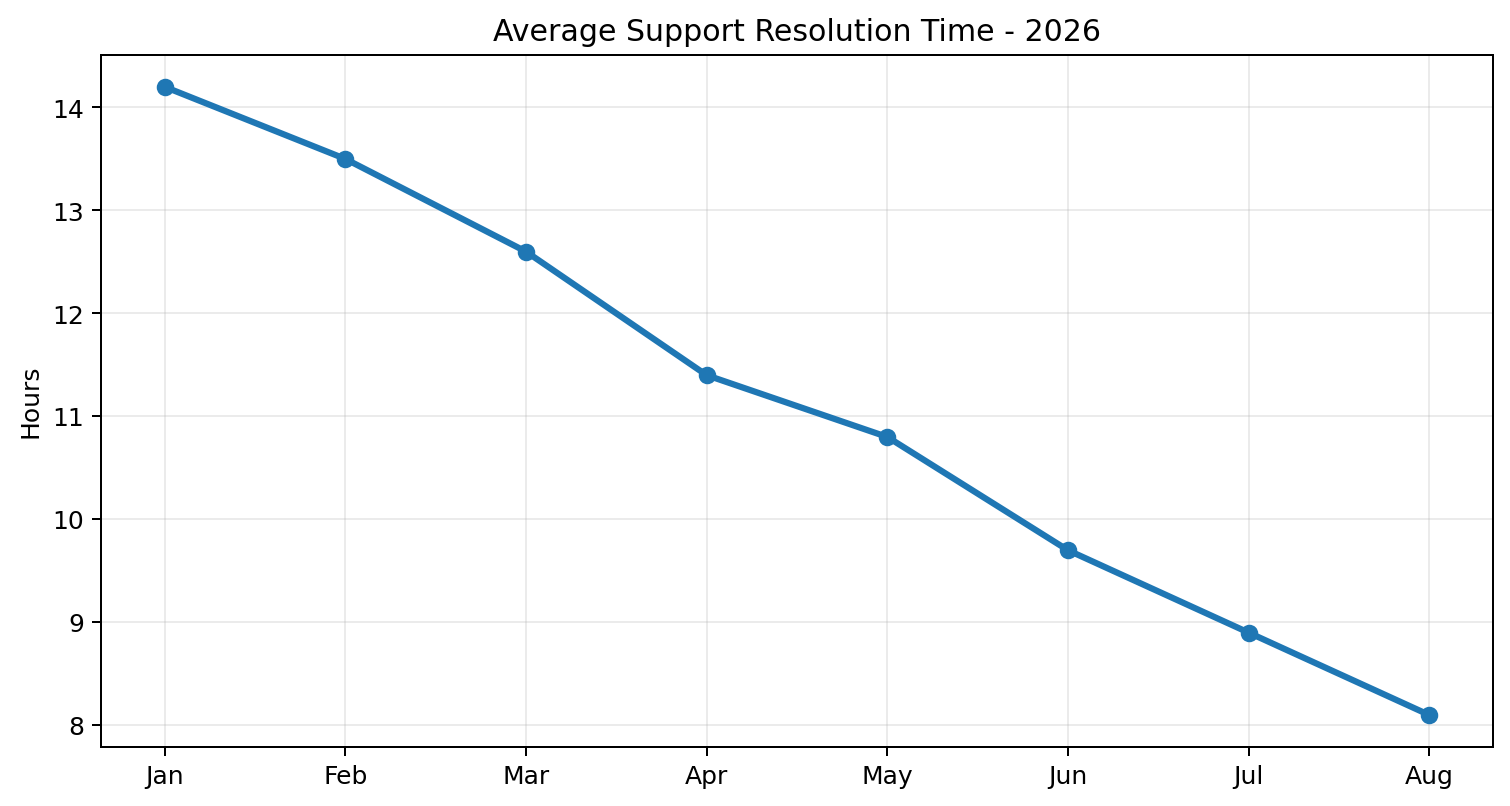

{'answer': 'Based on the line graph and text on page 7.0, the average support resolution time decreased from **14.2 hours in January** to **8.1 hours in August**. This represents a consistent downward trend throughout the first eight months of 2026.',
 'documents': [Document(id='ab1f3ca8-9f71-4655-bb2e-201a32358b72', metadata={'image_path': 'novacore_extracted_images\\page_7_image_1.png', 'modality': 'visual', 'page': 7.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='Based on the visual provided, here is the description of the business information:\n\n**Chart Type:** Line Graph\n**Title:** Average Support Resolution Time - 2026\n\n**Key Data Points & Values:**\n*   **Highest Value:** The highest average resolution time is recorded in **January**, at approximately **14.2 hours**.\n*   **Lowest Value:** The lowest average resolution time is recorded in **August**, at approximately **8.1 hours**.\n*   **Intermediate Points:**\n    *   February: ~13.5 hours\n    

In [38]:

ask_rag(
    "How did average support resolution time change from January to August?",
    show_images=True,
)


QUESTION:
What percentage of electricity at the Penang facility came from solar?

ANSWER:
Based on the pie chart titled "Penang Facility Electricity Mix - 2026" and the accompanying text on page 8, **34%** of the electricity at the Penang facility came from solar.

PINECONE RETRIEVED SOURCES:
1. Page 8.0 | visual
2. Page 8.0 | text

RETRIEVED VISUALS:


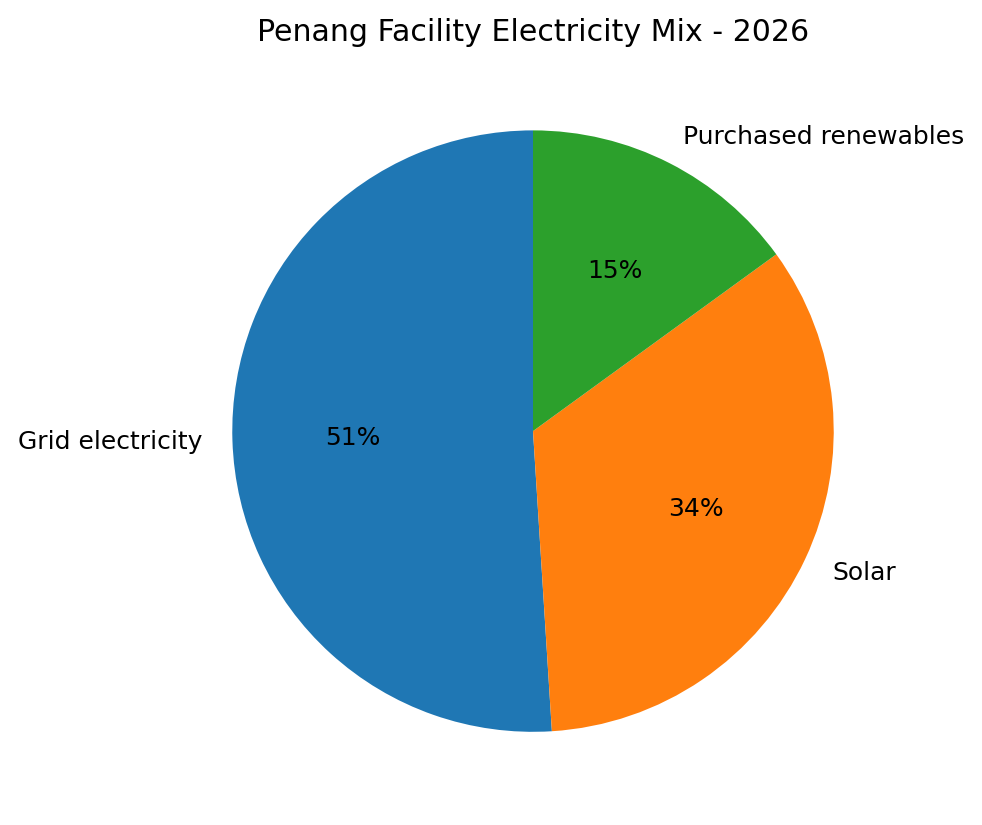

{'answer': 'Based on the pie chart titled "Penang Facility Electricity Mix - 2026" and the accompanying text on page 8, **34%** of the electricity at the Penang facility came from solar.',
 'documents': [Document(id='4d83b841-80fa-4219-a4bf-fddcb1497ac8', metadata={'image_path': 'novacore_extracted_images\\page_8_image_1.png', 'modality': 'visual', 'page': 8.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='Based on the visual provided, here is the description of the business information:\n\n**Chart Type:** Pie Chart\n**Title:** Penang Facility Electricity Mix - 2026\n\n**Key Data Points:**\nThe chart breaks down the electricity sources for the Penang facility for the year 2026 into three categories:\n\n*   **Grid electricity:** 51% (The largest portion, represented in blue)\n*   **Solar:** 34% (The second largest portion, represented in orange)\n*   **Purchased renewables:** 15% (The smallest portion, represented in green)\n\n**Analysis:**\n*   **Highest Value

In [39]:

ask_rag(
    "What percentage of electricity at the Penang facility came from solar?",
    show_images=True,
)

In [42]:

ask_rag(
    """
Give me a short FY2026 performance summary.
Include:
1. total revenue,
2. fastest-growing region,
3. support-resolution improvement,
4. solar share at the Penang facility.
"""
)


QUESTION:

Give me a short FY2026 performance summary.
Include:
1. total revenue,
2. fastest-growing region,
3. support-resolution improvement,
4. solar share at the Penang facility.


ANSWER:
Here is a short FY2026 performance summary for NovaCore Systems:

*   **Total Revenue:** FY2026 revenue reached **$132.0 million**, representing a 35.4% increase from the previous year (Page 3).
*   **Fastest-Growing Region:** **Europe** was the fastest-growing region, achieving 31% year-over-year revenue growth (Page 2).
*   **Support-Resolution Improvement:** The company achieved its target of an average resolution time under 9 hours, reaching **8.1 hours in August** (Page 2).
*   **Solar Share at Penang Facility:** Solar energy accounted for **34%** of the electricity mix at the Penang facility (Page 1, Page 8).

PINECONE RETRIEVED SOURCES:
1. Page 1.0 | visual
2. Page 3.0 | text
3. Page 2.0 | text
4. Page 8.0 | visual
5. Page 2.0 | table


{'answer': 'Here is a short FY2026 performance summary for NovaCore Systems:\n\n*   **Total Revenue:** FY2026 revenue reached **$132.0 million**, representing a 35.4% increase from the previous year (Page 3).\n*   **Fastest-Growing Region:** **Europe** was the fastest-growing region, achieving 31% year-over-year revenue growth (Page 2).\n*   **Support-Resolution Improvement:** The company achieved its target of an average resolution time under 9 hours, reaching **8.1 hours in August** (Page 2).\n*   **Solar Share at Penang Facility:** Solar energy accounted for **34%** of the electricity mix at the Penang facility (Page 1, Page 8).',
 'documents': [Document(id='b15ed977-24ed-4d21-85a7-97fb058cd541', metadata={'image_path': 'novacore_extracted_images\\page_1_image_1.png', 'modality': 'visual', 'page': 1.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='Based on the visual from the NovaCore FY2026 company report, here is the useful business information:\n\n**Faci